#



## 0. Cài đặt thư viện

In [1]:
# chỉ chạy một lần nếu chưa cài đặt các thư viện cần thiết
!pip install -q torch torchvision scikit-learn matplotlib seaborn tqdm pandas Pillow


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


#



## 1. Import & Cấu hình

In [2]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np

from src.dataset import build_dataloaders
from src.models import build_model
from src.train import train_model
from src.evaluate import evaluate_model, compare_models
from src.utils import plot_all, plot_model_comparison

CONFIG = {
    "data_dir"       : "./data",
    "output_dir"     : "./outputs",
    "img_size"       : 224,
    "epochs"         : 20,
    "lr"             : 1e-4,
    "weight_decay"   : 1e-4,
    "dropout"        : 0.3,
    "drop_path_rate" : 0.1,
    "patience"       : 7,
    "num_workers"    : 0,
    "batch_resnet"   : 16,
    "batch_convnext" : 16,
    "batch_vit"      : 8,
}

device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps"  if torch.backends.mps.is_available() else
    "cpu"
)

os.makedirs(CONFIG["output_dir"], exist_ok=True)

print(f"Device : {device}")
if device.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"Config : {CONFIG}")

Device : cuda
GPU    : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM   : 8.6 GB
Config : {'data_dir': './data', 'output_dir': './outputs', 'img_size': 224, 'epochs': 20, 'lr': 0.0001, 'weight_decay': 0.0001, 'dropout': 0.3, 'drop_path_rate': 0.1, 'patience': 7, 'num_workers': 0, 'batch_resnet': 16, 'batch_convnext': 16, 'batch_vit': 8}


## 2. Load dữ liệu

In [3]:
# Dùng CHUNG 1 bộ DataLoader cho ResNet + ConvNeXt
train_loader, val_loader, test_loader, class_names, class_weights = build_dataloaders(
    data_dir         = CONFIG["data_dir"],
    img_size         = CONFIG["img_size"],
    batch_size_train = CONFIG["batch_resnet"],
    batch_size_eval  = 32,
    num_workers      = CONFIG["num_workers"],
)

# Train loader riêng cho ViT (batch_size nhỏ hơn)
train_loader_vit, _, _, _, _ = build_dataloaders(
    data_dir         = CONFIG["data_dir"],
    img_size         = CONFIG["img_size"],
    batch_size_train = CONFIG["batch_vit"],
    batch_size_eval  = 32,
    num_workers      = CONFIG["num_workers"],
)

print(f"\nClass names  : {class_names}")
print(f"Train batches: {len(train_loader)} | ViT train: {len(train_loader_vit)}")
print(f"Val batches  : {len(val_loader)} | Test: {len(test_loader)}")

[Data] Classes : ['normal', 'pneumonia', 'tuberculosis']
[Data] Train=20450 | Val=2534 | Test=2569
[Data] Class weights : [0.8805191516876221, 1.368252158164978, 0.7512287497520447]
[Data] Classes : ['normal', 'pneumonia', 'tuberculosis']
[Data] Train=20450 | Val=2534 | Test=2569
[Data] Class weights : [0.8805191516876221, 1.368252158164978, 0.7512287497520447]

Class names  : ['normal', 'pneumonia', 'tuberculosis']
Train batches: 1279 | ViT train: 2557
Val batches  : 80 | Test: 81


### Kiểm tra một batch mẫu

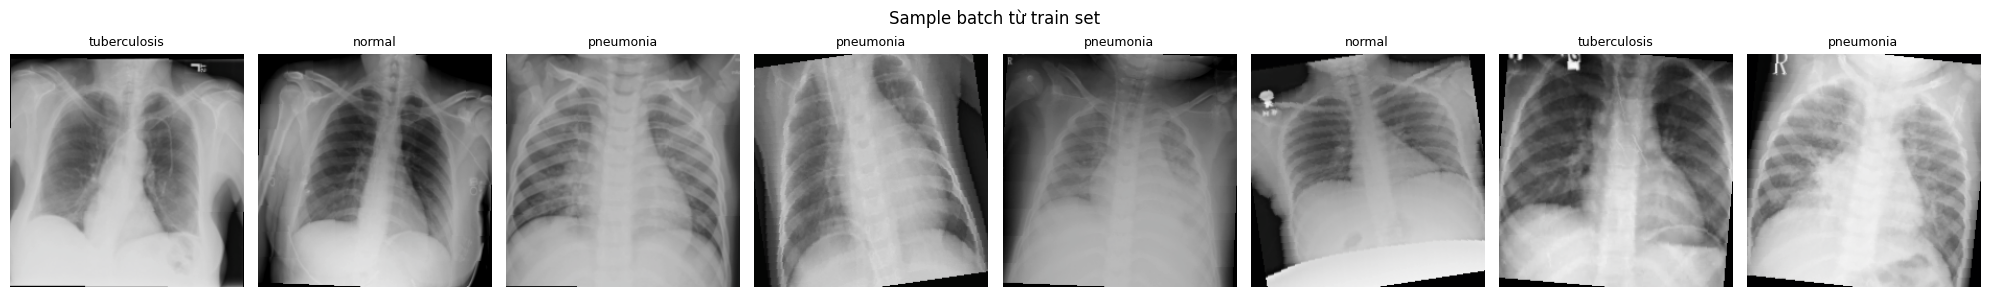

In [4]:
MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])

def denormalize(tensor):
    img = tensor.permute(1, 2, 0).numpy()
    return np.clip(img * STD + MEAN, 0, 1)

images, labels = next(iter(train_loader))  # đổi train_loader_r → train_loader
n_show = min(8, len(images))

fig, axes = plt.subplots(1, n_show, figsize=(2.5 * n_show, 3))
for i, ax in enumerate(axes):
    ax.imshow(denormalize(images[i]))
    ax.set_title(class_names[labels[i].item()], fontsize=9)
    ax.axis("off")

plt.suptitle("Sample batch từ train set", fontsize=12)
plt.tight_layout()
plt.show()

## 3. Huấn luyện ResNet-50

In [5]:
model_resnet = build_model(
    model_name = "resnet50",
    n_classes  = len(class_names),
    img_size   = CONFIG["img_size"],
    dropout    = CONFIG["dropout"],
)

history_resnet = train_model(
    model         = model_resnet,
    train_loader  = train_loader,      # đổi từ train_loader_r
    val_loader    = val_loader,        # đổi từ val_loader_r
    class_weights = class_weights,
    device        = device,
    epochs        = CONFIG["epochs"],
    lr            = CONFIG["lr"],
    weight_decay  = CONFIG["weight_decay"],
    patience      = CONFIG["patience"],
    output_dir    = CONFIG["output_dir"],
    model_name    = "resnet50",
)

[Model] ResNet-50 | n_classes=3
[Model] Total params: 23,529,283 | Trainable: 23,529,283


[resnet50] Epoch   1/20 | Loss 0.8538/0.9646 | F1 0.5636/0.5849 | LR 4.00e-05 | Time 533.7s


  ✓ Best model saved (val F1=0.5849)


[resnet50] Epoch   2/20 | Loss 0.7342/1.1183 | F1 0.6784/0.5664 | LR 7.00e-05 | Time 576.4s


[resnet50] Epoch   3/20 | Loss 0.6843/0.8696 | F1 0.7148/0.6747 | LR 1.00e-04 | Time 650.0s


...

[resnet50] Epoch  18/20 | Loss 0.5603/0.6668 | F1 0.7953/0.7776 | LR 4.34e-06 | Time 390.8s


  ✓ Best model saved (val F1=0.7776)


[resnet50] Epoch  19/20 | Loss 0.5575/0.6731 | F1 0.7911/0.7728 | LR 1.84e-06 | Time 391.3s


[resnet50] Epoch  20/20 | Loss 0.5527/0.6689 | F1 0.7985/0.7730 | LR 1.00e-06 | Time 392.9s


[resnet50] Training done. Best val F1 = 0.7776


### Training curves – ResNet-50

[Plot] Saved ./outputs\resnet50_training_curves.png


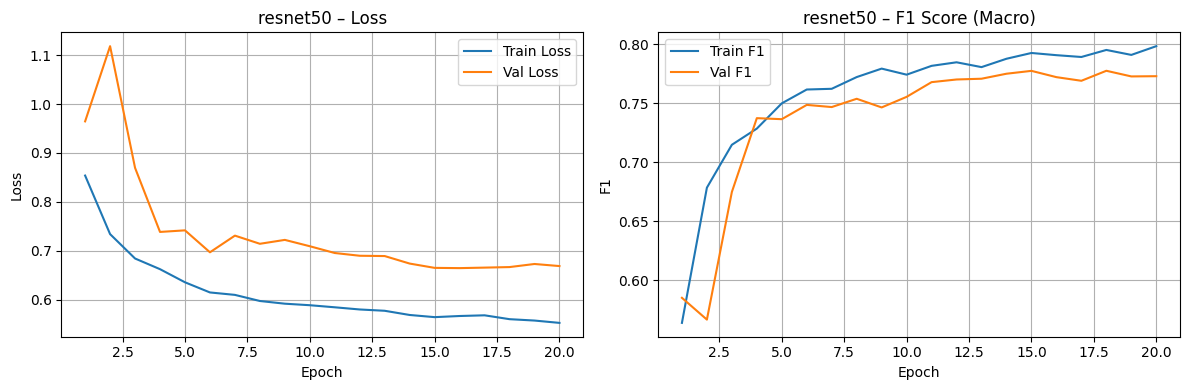

In [6]:
from src.utils import plot_training_curves
plot_training_curves(history_resnet, model_name="resnet50", output_dir=CONFIG["output_dir"])
plt.show()

#



## 4. Huấn luyện ConvNeXt-Tiny

In [7]:
model_convnext = build_model(
    model_name     = "convnext",
    n_classes      = len(class_names),
    img_size       = CONFIG["img_size"],
    dropout        = CONFIG["dropout"],
    drop_path_rate = CONFIG["drop_path_rate"],
)

history_convnext = train_model(
    model         = model_convnext,
    train_loader  = train_loader,
    val_loader    = val_loader,
    class_weights = class_weights,
    device        = device,
    epochs        = CONFIG["epochs"],
    lr            = CONFIG["lr"],
    weight_decay  = CONFIG["weight_decay"],
    patience      = CONFIG["patience"],
    output_dir    = CONFIG["output_dir"],
    model_name    = "convnext",
)

[Model] ConvNeXt-Tiny | n_classes=3 | drop_path=0.1
[Model] Total params: 27,822,435 | Trainable: 27,822,435


[convnext] Epoch   1/20 | Loss 0.8982/1.0178 | F1 0.5245/0.5183 | LR 4.00e-05 | Time 478.4s


  ✓ Best model saved (val F1=0.5183)


[convnext] Epoch   2/20 | Loss 0.7546/0.8503 | F1 0.6603/0.6885 | LR 7.00e-05 | Time 482.2s


  ✓ Best model saved (val F1=0.6885)


...

[convnext] Epoch  18/20 | Loss 0.5451/0.6738 | F1 0.7983/0.7701 | LR 4.34e-06 | Time 471.8s


  ✓ Best model saved (val F1=0.7701)


[convnext] Epoch  19/20 | Loss 0.5465/0.6646 | F1 0.7985/0.7694 | LR 1.84e-06 | Time 470.3s


[convnext] Epoch  20/20 | Loss 0.5464/0.6631 | F1 0.7958/0.7704 | LR 1.00e-06 | Time 482.0s


  ✓ Best model saved (val F1=0.7704)
[convnext] Training done. Best val F1 = 0.7704


### Training curves – ConvNeXt-Tiny

[Plot] Saved ./outputs\convnext_training_curves.png


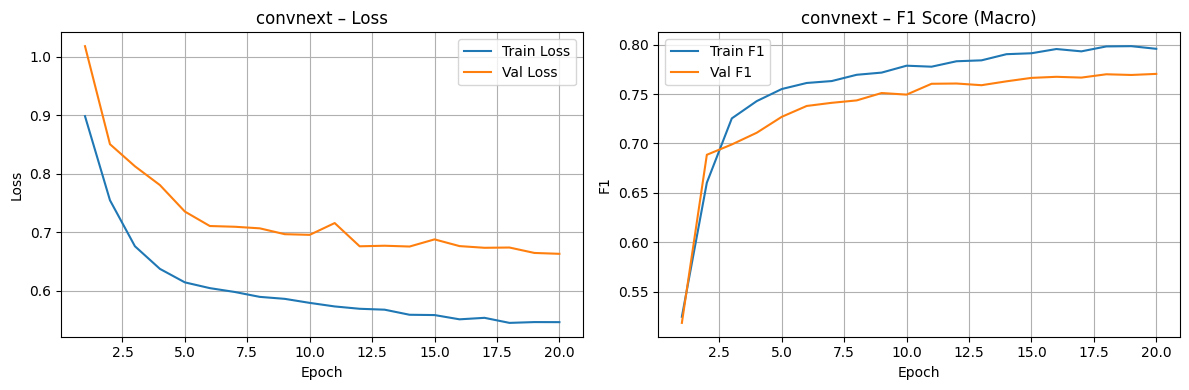

In [8]:
plot_training_curves(history_convnext, model_name="convnext", output_dir=CONFIG["output_dir"])
plt.show()

## 5. Huấn luyện ViT

In [9]:
model_vit = build_model(
    model_name = "vit",
    n_classes  = len(class_names),
    img_size   = CONFIG["img_size"],
    dropout    = CONFIG["dropout"],
)

history_vit = train_model(
    model         = model_vit,
    train_loader  = train_loader_vit,      
    val_loader    = val_loader,        # dùng chung val_loader
    class_weights = class_weights,
    device        = device,
    epochs        = CONFIG["epochs"],
    lr            = CONFIG["lr"],
    weight_decay  = CONFIG["weight_decay"],
    patience      = CONFIG["patience"],
    output_dir    = CONFIG["output_dir"],
    model_name    = "vit",
)

[Model] ViT-Tiny/16 | n_classes=3 | img_size=224
[Model] Total params: 21,666,819 | Trainable: 21,666,819


[vit] Epoch   1/20 | Loss 0.9162/1.0409 | F1 0.5456/0.5934 | LR 4.00e-05 | Time 405.2s


  ✓ Best model saved (val F1=0.5934)


[vit] Epoch   2/20 | Loss 0.7804/0.9397 | F1 0.6530/0.5928 | LR 7.00e-05 | Time 402.0s


[vit] Epoch   3/20 | Loss 0.7380/0.8474 | F1 0.6850/0.6669 | LR 1.00e-04 | Time 484.4s


...

  ✓ Best model saved (val F1=0.7417)


[vit] Epoch  18/20 | Loss 0.5911/0.7146 | F1 0.7750/0.7373 | LR 4.34e-06 | Time 396.9s


[vit] Epoch  19/20 | Loss 0.5905/0.7373 | F1 0.7733/0.7245 | LR 1.84e-06 | Time 396.1s


[vit] Epoch  20/20 | Loss 0.5899/0.7361 | F1 0.7754/0.7320 | LR 1.00e-06 | Time 400.2s


[vit] Training done. Best val F1 = 0.7417


### Training curves – ViT

[Plot] Saved ./outputs\vit_training_curves.png


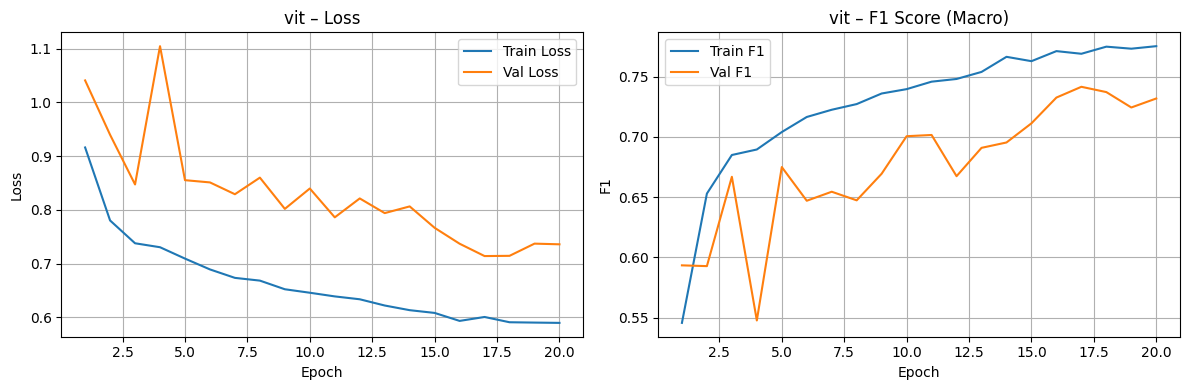

In [10]:
from src.utils import plot_training_curves
plot_training_curves(history_vit, model_name="vit", output_dir=CONFIG["output_dir"])
plt.show()

#



## 6. Đánh giá trên tập Test

In [12]:
metrics_resnet = evaluate_model(
    model       = model_resnet,
    test_loader = test_loader,
    class_names = class_names,
    device      = device,
    output_dir  = CONFIG["output_dir"],
    model_name  = "resnet50",
)


  RESNET50 — Test Results
  Accuracy  : 0.7622
  F1 (macro): 0.7740
  Precision : 0.7966
  Recall    : 0.7996
  ROC-AUC   : 0.9065

  Per-class Sensitivity & Specificity:
    normal                Sens=0.8108  Spec=0.7391
    pneumonia             Sens=0.9948  Spec=0.9145
    tuberculosis          Sens=0.5930  Spec=0.9920

  Model params  : 23,529,283
  VRAM peak     : 1000.2 MB
  Inference     : 22.42 ms/image

              precision    recall  f1-score   support

      normal       0.64      0.81      0.71       925
   pneumonia       0.77      0.99      0.87       580
tuberculosis       0.98      0.59      0.74      1064

    accuracy                           0.76      2569
   macro avg       0.80      0.80      0.77      2569
weighted avg       0.81      0.76      0.76      2569



In [13]:
metrics_convnext = evaluate_model(
    model       = model_convnext,
    test_loader = test_loader,
    class_names = class_names,
    device      = device,
    output_dir  = CONFIG["output_dir"],
    model_name  = "convnext",
)


  CONVNEXT — Test Results
  Accuracy  : 0.7606
  F1 (macro): 0.7726
  Precision : 0.7931
  Recall    : 0.7982
  ROC-AUC   : 0.9087

  Per-class Sensitivity & Specificity:
    normal                Sens=0.8032  Spec=0.7409
    pneumonia             Sens=0.9966  Spec=0.9145
    tuberculosis          Sens=0.5949  Spec=0.9874

  Model params  : 27,822,435
  VRAM peak     : 1028.0 MB
  Inference     : 10.66 ms/image

              precision    recall  f1-score   support

      normal       0.64      0.80      0.71       925
   pneumonia       0.77      1.00      0.87       580
tuberculosis       0.97      0.59      0.74      1064

    accuracy                           0.76      2569
   macro avg       0.79      0.80      0.77      2569
weighted avg       0.81      0.76      0.76      2569



In [14]:
metrics_vit = evaluate_model(
    model       = model_vit,
    test_loader = test_loader,
    class_names = class_names,
    device      = device,
    output_dir  = CONFIG["output_dir"],
    model_name  = "vit",
)


  VIT — Test Results
  Accuracy  : 0.7232
  F1 (macro): 0.7338
  Precision : 0.7666
  Recall    : 0.7662
  ROC-AUC   : 0.8925

  Per-class Sensitivity & Specificity:
    normal                Sens=0.7946  Spec=0.7068
    pneumonia             Sens=0.9862  Spec=0.8959
    tuberculosis          Sens=0.5179  Spec=0.9854

  Model params  : 21,666,819
  VRAM peak     : 768.5 MB
  Inference     : 10.59 ms/image

              precision    recall  f1-score   support

      normal       0.60      0.79      0.69       925
   pneumonia       0.73      0.99      0.84       580
tuberculosis       0.96      0.52      0.67      1064

    accuracy                           0.72      2569
   macro avg       0.77      0.77      0.73      2569
weighted avg       0.78      0.72      0.72      2569



#



## 7. Biểu đồ & So sánh

[Plot] Saved ./outputs\ResNet-50_confusion_matrix.png


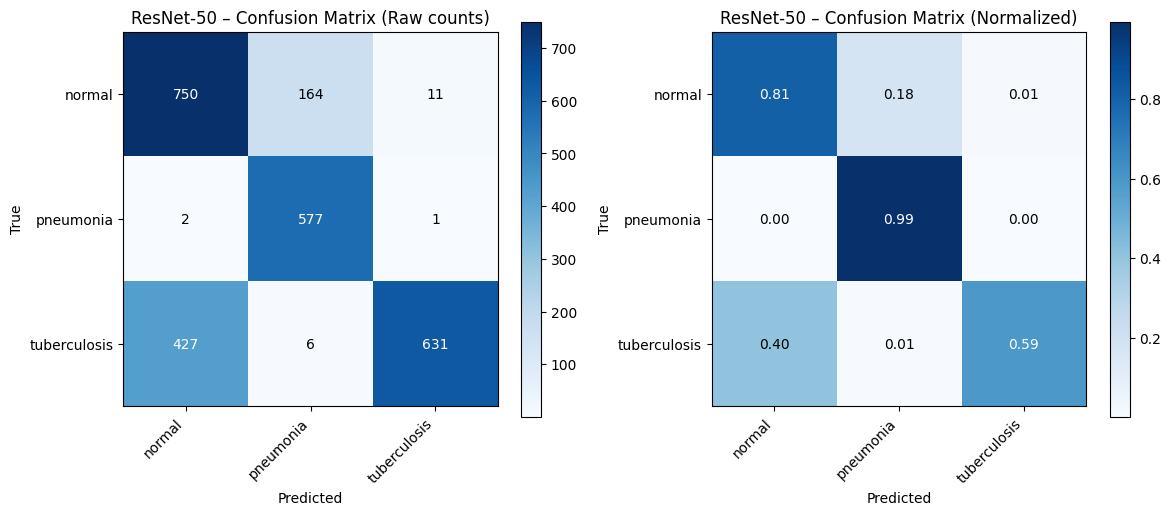

[Plot] Saved ./outputs\ConvNeXt-Tiny_confusion_matrix.png


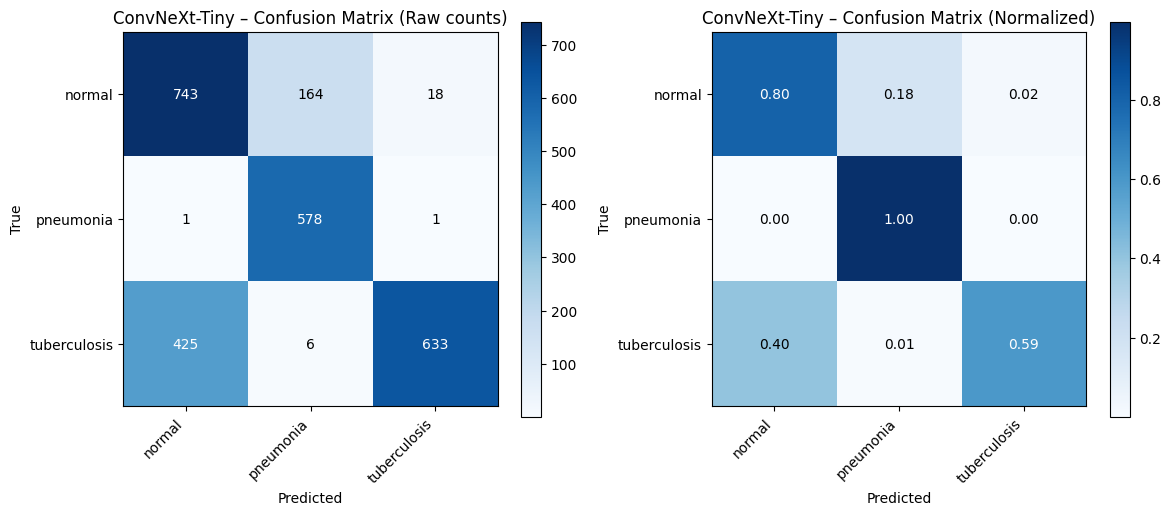

FileNotFoundError: [Errno 2] No such file or directory: './outputs\\ViT-Tiny/16_confusion_matrix.png'

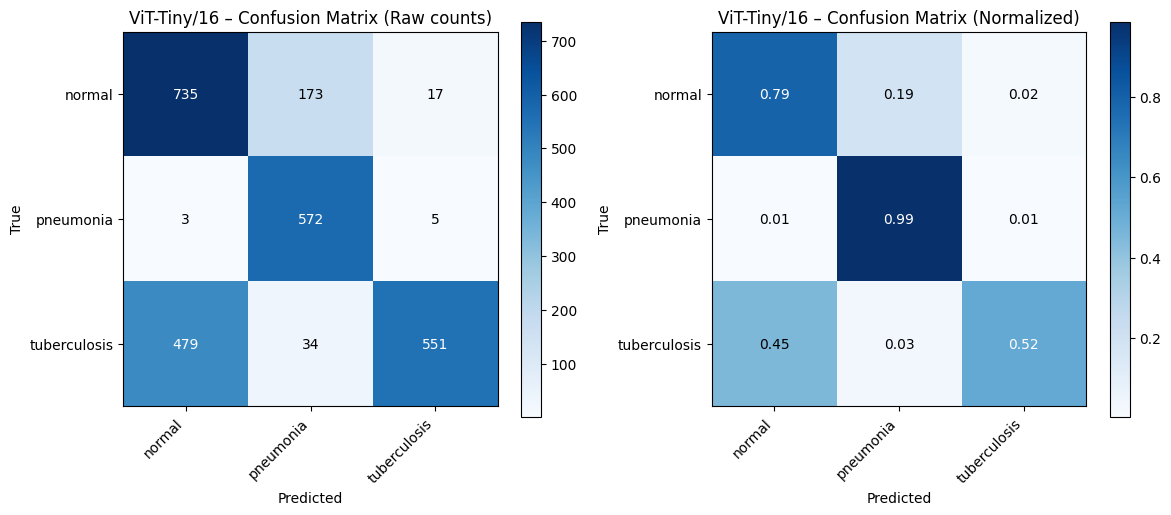

In [20]:
from src.utils import plot_confusion_matrix, plot_roc_curve

metrics_by_model = {
    "ResNet-50": metrics_resnet,
    "ConvNeXt-Tiny": metrics_convnext,
    "ViT-Tiny/16": metrics_vit,
}

for model_name, metrics in metrics_by_model.items():
    plot_confusion_matrix(
        metrics["y_true"], metrics["y_pred"],
        class_names, model_name, CONFIG["output_dir"],
    )
    plt.show()

[Plot] Saved ./outputs\ResNet-50_roc_curve.png


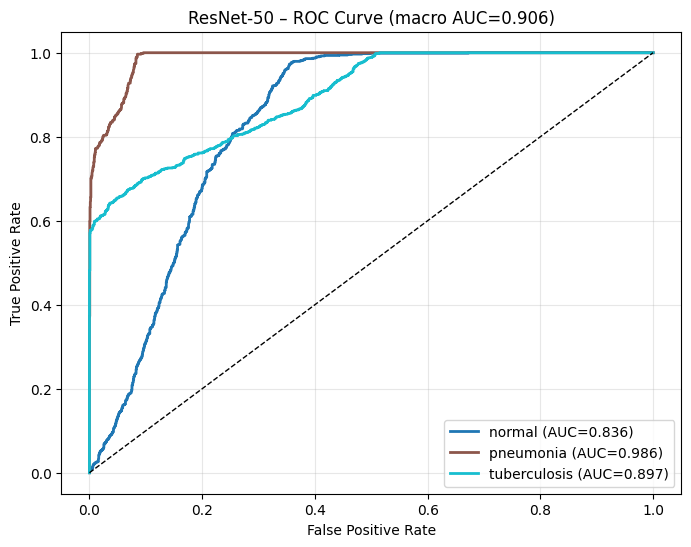

[Plot] Saved ./outputs\ConvNeXt-Tiny_roc_curve.png


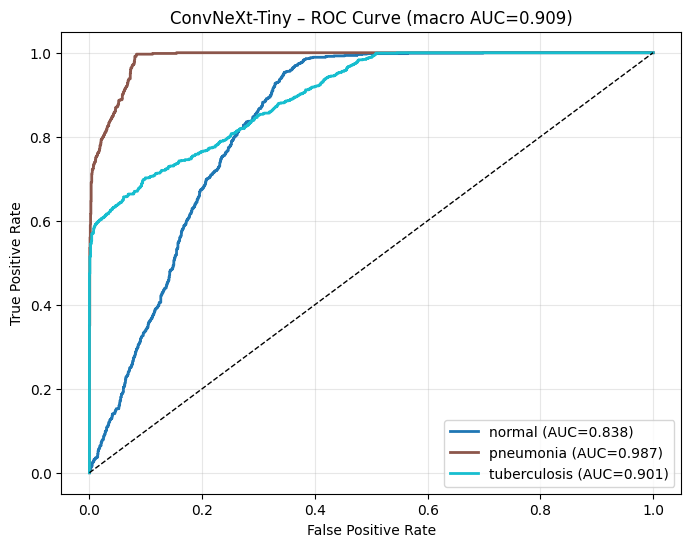

FileNotFoundError: [Errno 2] No such file or directory: './outputs\\ViT-Tiny/16_roc_curve.png'

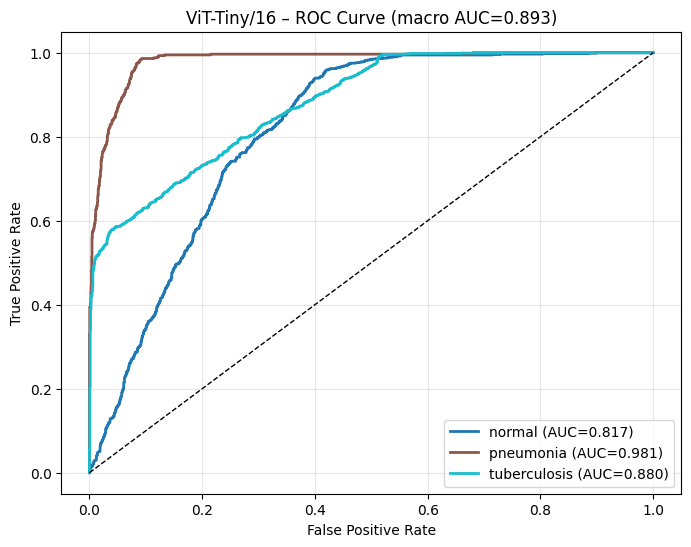

In [21]:
for model_name, metrics in metrics_by_model.items():
    plot_roc_curve(
        metrics["y_true"], metrics["y_proba"],
        class_names, model_name, CONFIG["output_dir"],
    )
    plt.show()


  MODEL COMPARISON
  Model                  Acc      F1     AUC       Params   VRAM(MB)   ms/img
  ----------------------------------------------------------------------------
  ResNet-50           0.7622  0.7740  0.9065   23,529,283     1000.2    22.42
  ConvNeXt-Tiny       0.7606  0.7726  0.9087   27,822,435     1028.0    10.66
  ViT-Tiny/16         0.7232  0.7338  0.8925   21,666,819      768.5    10.59

[Plot] Saved ./outputs\model_comparison.png


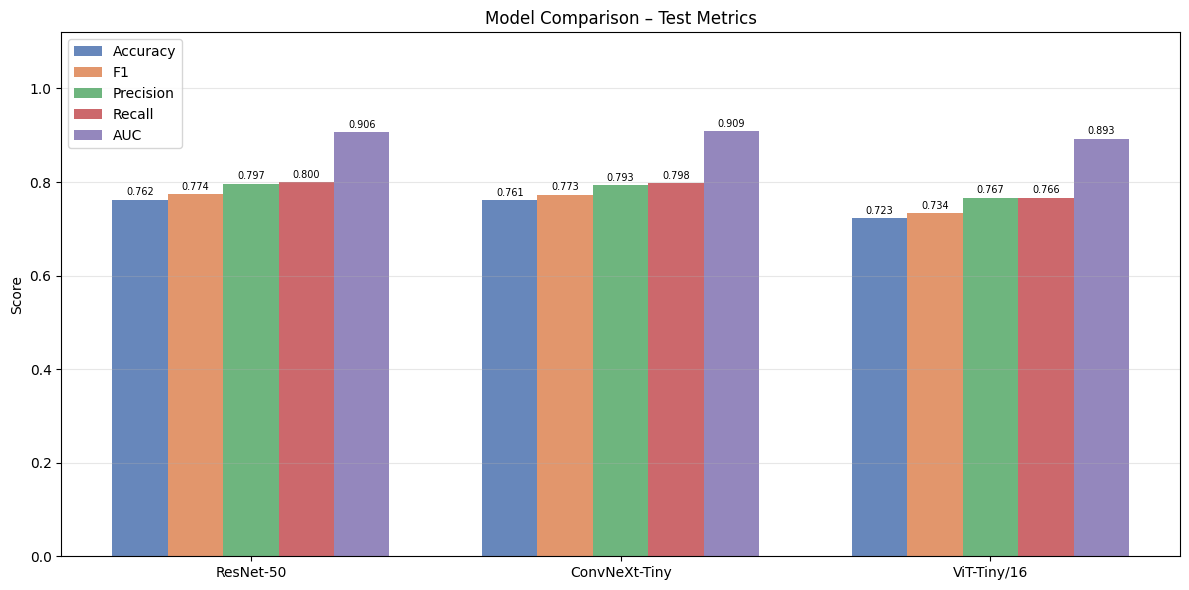

In [22]:
compare_models(metrics_by_model)
plot_model_comparison(metrics_by_model, output_dir=CONFIG["output_dir"])
plt.show()

## 8. Tổng kết

Tất cả checkpoint (`.pth`) và biểu đồ (`.png`) đã được lưu vào thư mục `outputs/`.

| File | Nội dung |
|---|---|
| `resnet50_best.pth` | Best checkpoint ResNet-50 |
| `convnext_best.pth` | Best checkpoint ConvNeXt-Tiny |
| `vit_best.pth`| Best checkpoint ViT|
| `*_training_curves.png` | Loss & F1 theo epoch |
| `*_confusion_matrix.png` | Confusion Matrix (raw + normalized) |
| `*_roc_curve.png` | ROC Curve per-class + macro |
| `model_comparison.png` | Bar chart so sánh 3 model |